# Sentiment Classification des Leaders Politiques — Archelec
Fine-tuning CamemBERT + **Focal Loss** sur les **384 mentions annotées** (2 classes : positif / négatif).

**Pipeline :**
1. Chargement des 384 lignes annotées (`leaders_mentions_annotated.xlsx`)
2. Fine-tuning `camembert-base` + Focal Loss → meilleure détection des négatifs
3. Évaluation : classification report + matrice de confusion
4. Application sur les 5 958 lignes non annotées → prédiction complète
5. Analyse finale : sentiment par président / année / bloc / parti

## 0 — Installation des dépendances

In [1]:
# Réinstalle PyTorch compatible avec CUDA 12.9 (le cu130 installé par défaut ne fonctionne pas)
!pip install -q torch --index-url https://download.pytorch.org/whl/cu124
!pip install -q transformers accelerate scikit-learn openpyxl seaborn


## 1 — Imports & configuration

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

NOTEBOOK_DIR   = Path(os.getcwd())
ROOT_DIR       = NOTEBOOK_DIR.parent

OUTPUT_DIR     = ROOT_DIR / 'data' / 'results' / 'output_best_model'
INPUT_FILE     = OUTPUT_DIR / 'leaders_mentions_annotated.xlsx'
FINAL_FILE     = OUTPUT_DIR / 'leaders_sentiment_corpus.xlsx'
MODEL_SAVE_DIR = ROOT_DIR / 'data' / 'results' / 'sentiment_model_focal'
GRAPHS_DIR     = OUTPUT_DIR / 'graphs'

for d in [MODEL_SAVE_DIR, GRAPHS_DIR]:
    os.makedirs(d, exist_ok=True)

LABEL_MAP  = {'négatif': 0, 'positif': 1}
ID2LABEL   = {0: 'négatif', 1: 'positif'}
LABEL_LIST = ['négatif', 'positif']
COLORS     = {'négatif': '#e74c3c', 'positif': '#2ecc71'}

print(f'INPUT  : {INPUT_FILE}')
print(f'MODEL  : {MODEL_SAVE_DIR}')
print(f'GRAPHS : {GRAPHS_DIR}')


## 2 — Chargement et exploration des 384 lignes annotées

In [3]:
df_all = pd.read_excel(INPUT_FILE)

# Extraire uniquement les lignes avec un label valide
df = df_all[df_all["sentiment_president"].isin(["positif", "négatif"])].copy()
df["label"] = df["sentiment_president"].map(LABEL_MAP)

print(f"Lignes annotées : {len(df)}")
print()
print("Distribution des labels :")
print(df["sentiment_president"].value_counts().to_string())
print()
print("Par président :")
print(df.groupby(["actual_president", "sentiment_president"]).size().to_string())
df.head(3)


Lignes annotées : 200

Distribution des labels :
sentiment_president
positif    186
négatif     14

Par président :
actual_president  sentiment_president
Georges Pompidou  négatif                 14
                  positif                186


,annee,departement,parti,file_id,entite,actual_president,text,sentiment_president,label
0,1973,Ain,non mentionné,EL065_L_1973_03_001_01_1_PF_05,Georges POMPIDOU,Georges Pompidou,"étiquette, avec la même volonté d'être utile ...",positif,1
1,1973,Ain,Républicain indépendant;Union des républicains...,EL065_L_1973_03_001_02_1_PF_01,Georges POMPIDOU,Georges Pompidou,"rages, accompagné de mon fidèle ami M. Michel ...",positif,1
2,1973,Aisne,Alliance républicaine indépendante et libérale,EL065_L_1973_03_002_01_1_PF_05,Georges Pompidou,Georges Pompidou,tion de l'Aisne\nGeorges LESIMON Commerçant CI...,positif,1


## 3 — Fine-tuning CamemBERT + Focal Loss
- `camembert-base` → `CamembertForSequenceClassification` (2 classes)
- Input : colonne `text`, `max_length=256`, split stratifié 80/10/10
- **Focal Loss** (alpha=0.75, gamma=2.0) — meilleure détection des négatifs
- `save_total_limit=1` pour éviter de saturer le disque

In [8]:
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    CamembertTokenizer,
    CamembertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

# ── Split stratifié 80 / 10 / 10 ─────────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.20,
    stratify=df["label"].tolist(),
    random_state=42,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train : {len(X_train)}  |  Val : {len(X_val)}  |  Test : {len(X_test)}")
print(f"  Train labels : { {ID2LABEL[l]: y_train.count(l) for l in LABEL_MAP.values()} }")


Train : 307  |  Val : 38  |  Test : 39
  Train labels : {'négatif': 92, 'positif': 215}


In [9]:
MAX_LENGTH = 256
tokenizer  = CamembertTokenizer.from_pretrained("camembert-base")

class SentimentDataset(TorchDataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

train_dataset = SentimentDataset(X_train, y_train)
val_dataset   = SentimentDataset(X_val,   y_val)
test_dataset  = SentimentDataset(X_test,  y_test)
print("Datasets créés.")


Datasets créés.


In [10]:
import torch
import torch.nn.functional as F
from transformers import (
    CamembertForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback,
)
from sklearn.metrics import accuracy_score, f1_score

# ── Focal Loss ────────────────────────────────────────────────────────────────
def focal_loss(logits, labels, alpha=0.75, gamma=2.0):
    ce      = F.cross_entropy(logits, labels, reduction='none')
    pt      = torch.exp(-ce)
    alpha_t = torch.where(labels == 0,
                          torch.tensor(alpha,     device=logits.device),
                          torch.tensor(1 - alpha, device=logits.device))
    return (alpha_t * (1 - pt) ** gamma * ce).mean()

class FocalLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = focal_loss(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': float(accuracy_score(labels, preds)),
        'f1_macro': float(f1_score(labels, preds, average='macro', zero_division=0)),
    }

use_gpu = torch.cuda.is_available()
print(f'Device : {"GPU" if use_gpu else "CPU"}')
print('Focal Loss alpha=0.75, gamma=2.0')

model_ft = CamembertForSequenceClassification.from_pretrained(
    'camembert-base', num_labels=2, id2label=ID2LABEL, label2id=LABEL_MAP,
)

training_args = TrainingArguments(
    output_dir=str(MODEL_SAVE_DIR),
    num_train_epochs=15,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=10,
    report_to='none',
    fp16=use_gpu,
    warmup_steps=50,
    save_total_limit=1,
)

trainer = FocalLossTrainer(
    model=model_ft,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()


Device : GPU
Focal Loss alpha=0.75, gamma=2.0


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2476.93it/s]
[transformers] CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.063525,0.061448,0.868421,0.810568
2,0.044568,0.023331,0.947368,0.936027
3,0.025956,0.013929,0.973684,0.967100
4,0.009005,0.009295,0.921053,0.910588
5,0.002998,0.003153,1.000000,1.000000
6,0.005162,0.009344,0.973684,0.967100
7,0.002397,0.017241,0.973684,0.967100
8,0.000639,0.006624,0.973684,0.967100


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.22it/s]


TrainOutput(global_step=312, training_loss=0.019811569239745717, metrics={'train_runtime': 89.3383, 'train_samples_per_second': 51.546, 'train_steps_per_second': 6.548, 'total_flos': 323100375982080.0, 'train_loss': 0.019811569239745717, 'epoch': 8.0})

In [11]:
trainer.save_model(str(MODEL_SAVE_DIR))
tokenizer.save_pretrained(str(MODEL_SAVE_DIR))
print(f'Modèle sauvegardé : {MODEL_SAVE_DIR}')


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.21it/s]

Modèle sauvegardé : /home/onyxia/work/Named_Entity_Extraction_Archelec_Corpus/projet_archelec/data/results/sentiment_model_focal


## 4 — Évaluation sur le test set

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

pred_output   = trainer.predict(test_dataset)
y_pred        = np.argmax(pred_output.predictions, axis=-1)
y_pred_labels = [ID2LABEL[p] for p in y_pred]
y_true_labels = [ID2LABEL[t] for t in y_test]

print("=" * 50)
print("Classification Report — Test Set")
print("=" * 50)
print(classification_report(y_true_labels, y_pred_labels, target_names=LABEL_LIST))


Classification Report — Test Set
              precision    recall  f1-score   support

     négatif       0.92      0.92      0.92        12
     positif       0.96      0.96      0.96        27

    accuracy                           0.95        39
   macro avg       0.94      0.94      0.94        39
weighted avg       0.95      0.95      0.95        39



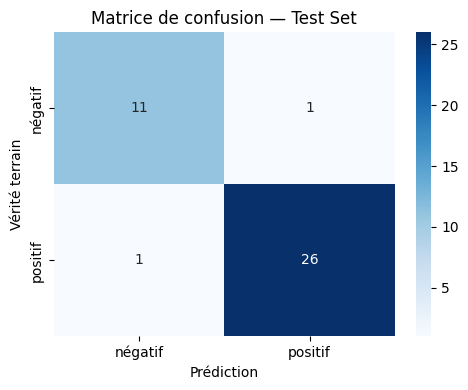

In [13]:
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=LABEL_LIST)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=LABEL_LIST, yticklabels=LABEL_LIST, ax=ax,
)
ax.set_xlabel("Prédiction")
ax.set_ylabel("Vérité terrain")
ax.set_title("Matrice de confusion — Test Set")
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "confusion_matrix.png", dpi=150)
plt.show()


## 5 — Analyse & visualisations

In [14]:
# ── Mapping bloc politique ────────────────────────────────────────────────────
GAUCHE_KW = [
    "socialiste", "communiste", "lutte ouvrière", "parti socialiste unifié",
    "radicaux de gauche", "sfio", "gauche", "trotsk", "ligue communiste",
]
DROITE_KW = [
    "rassemblement pour la République", "rpr", "républicain indépendant",
    "union des républicains", "front national", "alliance républicaine",
    "gaulliste", "cnip", "droite",
]
CENTRE_KW = [
    "union pour la démocratie", "udf", "centre démocrate", "mrp", "cds",
    "centre", "réformateur", "libéral", "radical",
]

def get_bloc(parti):
    if not isinstance(parti, str):
        return "non classé"
    p = parti.lower()
    if any(kw in p for kw in GAUCHE_KW):
        return "gauche"
    if any(kw in p for kw in DROITE_KW):
        return "droite"
    if any(kw in p for kw in CENTRE_KW):
        return "centre"
    return "non classé"

df["bloc_politique"] = df["parti"].apply(get_bloc)
print("Bloc politique :")
print(df["bloc_politique"].value_counts().to_string())


Bloc politique :
bloc_politique
droite        219
gauche         93
centre         44
non classé     28


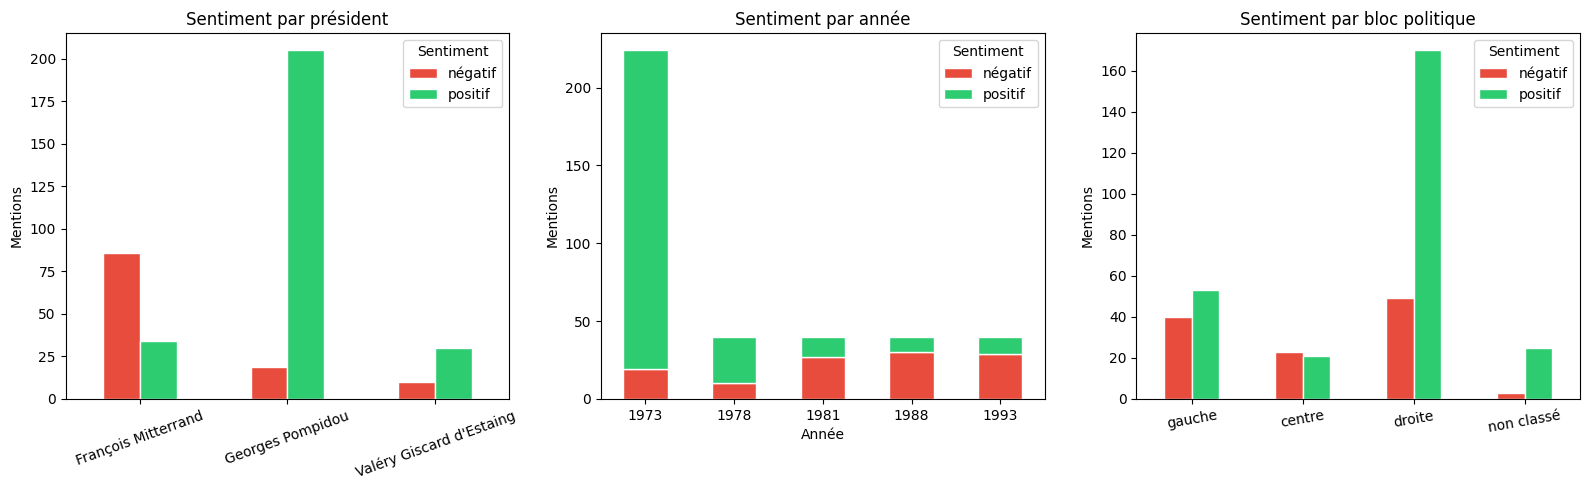

Graphique sauvegardé : /home/onyxia/work/Named_Entity_Extraction_Archelec_Corpus/projet_archelec/data/results/output_best_model/graphs/sentiment_analyse.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Par président ─────────────────────────────────────────────────────────────
pres = (
    df.groupby(["actual_president", "sentiment_president"])
    .size().unstack(fill_value=0)
    .reindex(columns=LABEL_LIST, fill_value=0)
)
pres.plot(kind="bar", ax=axes[0], color=[COLORS[l] for l in LABEL_LIST], edgecolor="white")
axes[0].set_title("Sentiment par président")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mentions")
axes[0].legend(title="Sentiment")
axes[0].tick_params(axis="x", rotation=20)

# ── Par année ─────────────────────────────────────────────────────────────────
annee = (
    df.groupby(["annee", "sentiment_president"])
    .size().unstack(fill_value=0)
    .reindex(columns=LABEL_LIST, fill_value=0)
    .sort_index()
)
annee.plot(kind="bar", stacked=True, ax=axes[1], color=[COLORS[l] for l in LABEL_LIST], edgecolor="white")
axes[1].set_title("Sentiment par année")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Mentions")
axes[1].legend(title="Sentiment")
axes[1].tick_params(axis="x", rotation=0)

# ── Par bloc politique ────────────────────────────────────────────────────────
bloc = (
    df.groupby(["bloc_politique", "sentiment_president"])
    .size().unstack(fill_value=0)
    .reindex(index=["gauche","centre","droite","non classé"], columns=LABEL_LIST, fill_value=0)
)
bloc.plot(kind="bar", ax=axes[2], color=[COLORS[l] for l in LABEL_LIST], edgecolor="white")
axes[2].set_title("Sentiment par bloc politique")
axes[2].set_xlabel("")
axes[2].set_ylabel("Mentions")
axes[2].legend(title="Sentiment")
axes[2].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.savefig(GRAPHS_DIR / "sentiment_analyse.png", dpi=150)
plt.show()
print(f"Graphique sauvegardé : {GRAPHS_DIR / 'sentiment_analyse.png'}")


In [16]:
# ── Sauvegarde finale ─────────────────────────────────────────────────────────
df.to_excel(FINAL_FILE, index=False, engine="openpyxl")
print(f"Fichier sauvegardé : {FINAL_FILE}")
print(f"  Lignes    : {len(df)}")
print(f"  Colonnes  : {df.columns.tolist()}")


Fichier sauvegardé : /home/onyxia/work/Named_Entity_Extraction_Archelec_Corpus/projet_archelec/data/results/output_best_model/leaders_sentiment_corpus.xlsx
  Lignes    : 384
  Colonnes  : ['annee', 'departement', 'parti', 'file_id', 'entite', 'actual_president', 'text', 'sentiment_president', 'label', 'bloc_politique']


## 6 — Prédiction sur le corpus complet (5 958 lignes non annotées)
On applique le modèle fine-tuné sur toutes les lignes sans label.
> **Ne lancer que si les métriques §4 sont satisfaisantes (F1 négatif > 0.55)**

In [17]:
from tqdm.auto import tqdm

df_corpus      = pd.read_excel(INPUT_FILE)
df_annotated   = df_corpus[df_corpus['sentiment_president'].isin(['positif','négatif'])].copy()
df_unannotated = df_corpus[~df_corpus['sentiment_president'].isin(['positif','négatif'])].copy()

print(f'Annotées (vérité terrain) : {len(df_annotated)}')
print(f'À prédire                 : {len(df_unannotated)}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_ft.eval()
model_ft.to(device)

BATCH = 64
texts_to_pred = df_unannotated['text'].fillna('').tolist()
all_preds, all_probs = [], []

for start in tqdm(range(0, len(texts_to_pred), BATCH), desc='Prédiction corpus'):
    enc = tokenizer(
        texts_to_pred[start:start+BATCH],
        truncation=True, padding='max_length',
        max_length=MAX_LENGTH, return_tensors='pt'
    ).to(device)
    with torch.no_grad():
        logits = model_ft(**enc).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()
    all_preds.extend(probs.argmax(axis=1).tolist())
    all_probs.extend(probs[:, 1].tolist())

df_unannotated = df_unannotated.copy()
df_unannotated['sentiment_president'] = [ID2LABEL[p] for p in all_preds]
df_unannotated['prob_positif']        = all_probs
df_annotated['prob_positif']          = float('nan')

df_full = pd.concat([df_annotated, df_unannotated], ignore_index=True)
df_full['bloc_politique'] = df_full['parti'].apply(get_bloc)

print(f'\nDistribution finale ({len(df_full)} lignes) :')
print(df_full['sentiment_president'].value_counts())
df_full.to_excel(FINAL_FILE, index=False, engine='openpyxl')
print(f'\nSauvegardé : {FINAL_FILE}')


Annotées (vérité terrain) : 384
À prédire                 : 5958


Prédiction corpus: 100%|██████████| 94/94 [00:32<00:00,  2.86it/s]



Distribution finale (6342 lignes) :
sentiment_president
négatif    3241
positif    3101
Name: count, dtype: int64

Sauvegardé : /home/onyxia/work/Named_Entity_Extraction_Archelec_Corpus/projet_archelec/data/results/output_best_model/leaders_sentiment_corpus.xlsx


## 7 — Analyse politique complète du corpus

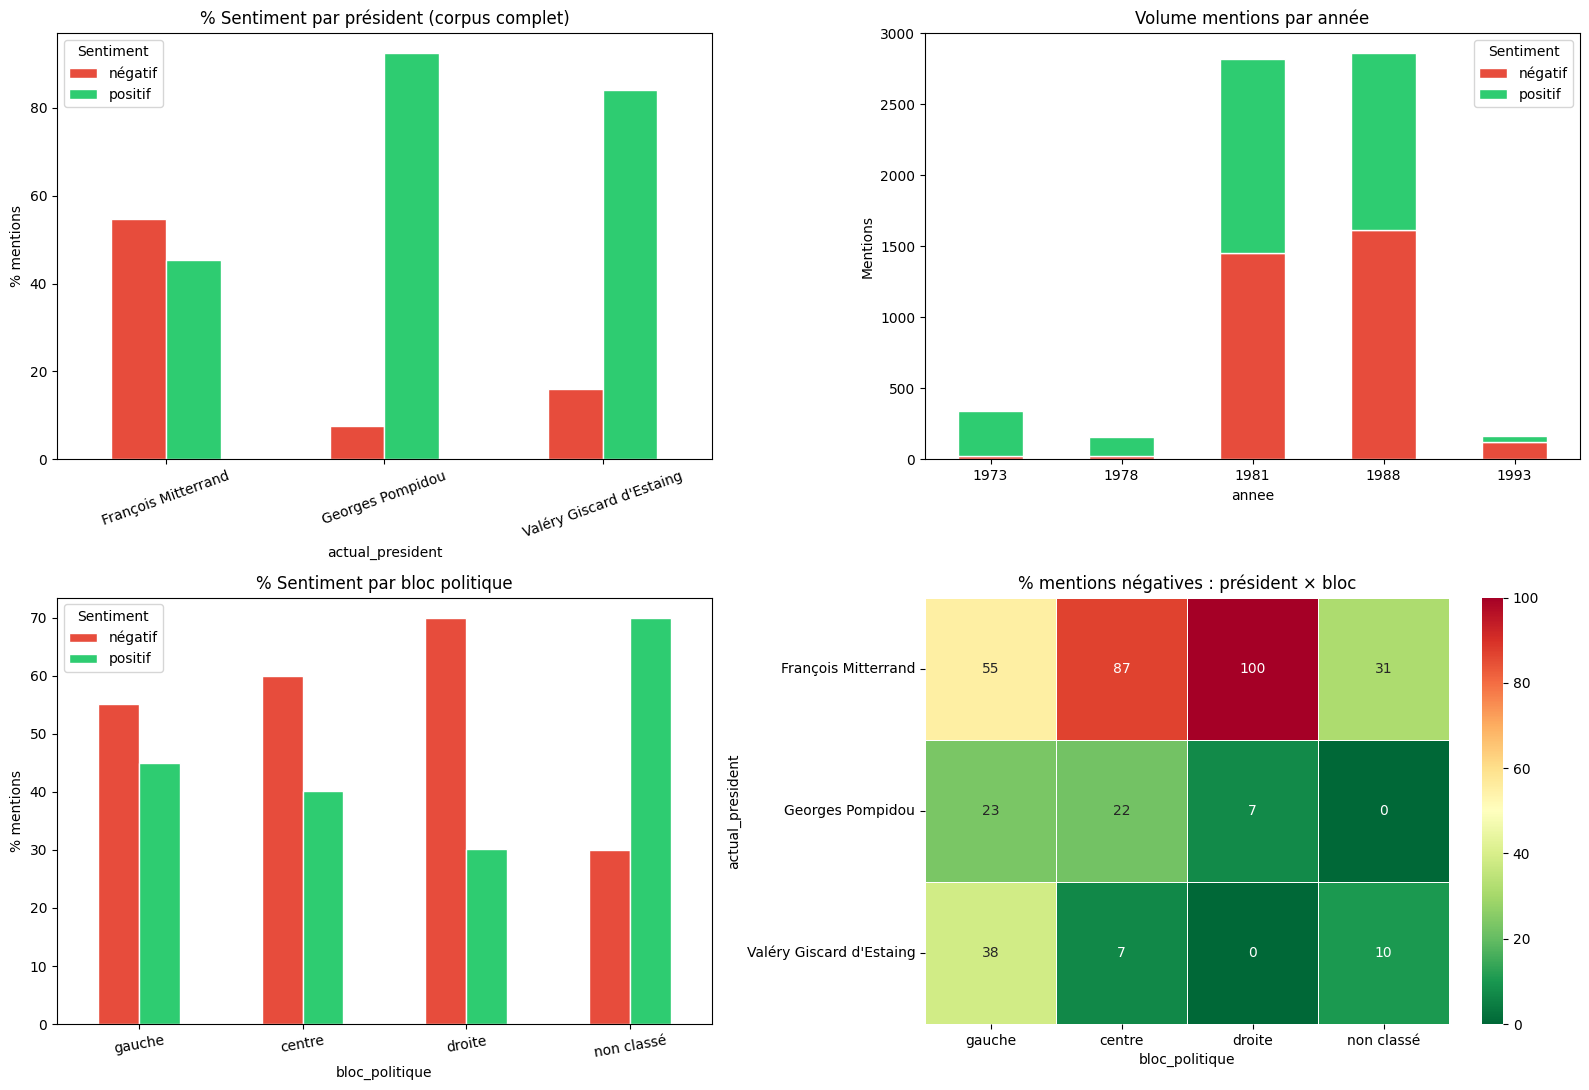

Graphique : /home/onyxia/work/Named_Entity_Extraction_Archelec_Corpus/projet_archelec/data/results/output_best_model/graphs/analyse_corpus_complet.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 7.1 % sentiment par président
pres = (df_full.groupby(['actual_president','sentiment_president'])
        .size().unstack(fill_value=0).reindex(columns=LABEL_LIST, fill_value=0))
pres_pct = pres.div(pres.sum(axis=1), axis=0) * 100
pres_pct.plot(kind='bar', ax=axes[0,0], color=[COLORS[l] for l in LABEL_LIST], edgecolor='white')
axes[0,0].set_title('% Sentiment par président (corpus complet)')
axes[0,0].set_ylabel('% mentions')
axes[0,0].tick_params(axis='x', rotation=20)
axes[0,0].legend(title='Sentiment')

# 7.2 Volume par année
annee = (df_full.groupby(['annee','sentiment_president'])
         .size().unstack(fill_value=0).reindex(columns=LABEL_LIST, fill_value=0).sort_index())
annee.plot(kind='bar', stacked=True, ax=axes[0,1],
           color=[COLORS[l] for l in LABEL_LIST], edgecolor='white')
axes[0,1].set_title('Volume mentions par année')
axes[0,1].set_ylabel('Mentions')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(title='Sentiment')

# 7.3 % sentiment par bloc
bloc = (df_full.groupby(['bloc_politique','sentiment_president'])
        .size().unstack(fill_value=0)
        .reindex(index=['gauche','centre','droite','non classé'], columns=LABEL_LIST, fill_value=0))
bloc_pct = bloc.div(bloc.sum(axis=1), axis=0) * 100
bloc_pct.plot(kind='bar', ax=axes[1,0], color=[COLORS[l] for l in LABEL_LIST], edgecolor='white')
axes[1,0].set_title('% Sentiment par bloc politique')
axes[1,0].set_ylabel('% mentions')
axes[1,0].tick_params(axis='x', rotation=10)
axes[1,0].legend(title='Sentiment')

# 7.4 Heatmap % négatif : président × bloc
heat = (df_full.groupby(['actual_president','bloc_politique','sentiment_president'])
        .size().unstack(fill_value=0).reindex(columns=LABEL_LIST, fill_value=0))
heat['pct_negatif'] = heat['négatif'] / (heat['négatif'] + heat['positif']) * 100
heat_pivot = heat['pct_negatif'].unstack('bloc_politique')
heat_pivot = heat_pivot.reindex(columns=['gauche','centre','droite','non classé'])
sns.heatmap(heat_pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            vmin=0, vmax=100, ax=axes[1,1], linewidths=0.5)
axes[1,1].set_title('% mentions négatives : président × bloc')

plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'analyse_corpus_complet.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Graphique : {GRAPHS_DIR}/analyse_corpus_complet.png')


In [19]:
print('=' * 65)
print('TOP PARTIS NÉGATIFS / POSITIFS par président')
print('=' * 65)
for pname in df_full['actual_president'].dropna().unique():
    sub = df_full[df_full['actual_president'] == pname]
    print(f'\n{pname} — négatifs :')
    print(sub[sub['sentiment_president']=='négatif']['parti'].value_counts().head(5).to_string())
    print(f'{pname} — positifs :')
    print(sub[sub['sentiment_president']=='positif']['parti'].value_counts().head(5).to_string())


TOP PARTIS NÉGATIFS / POSITIFS par président

Georges Pompidou — négatifs :
parti
Front national                                        13
Union des républicains de progrès                      3
Mouvement réformateur                                  1
Front national;Front uni de soutien au Sud-Vietnam     1
Alliance républicaine indépendante et libérale         1
Georges Pompidou — positifs :
parti
Union des républicains de progrès                                                                                                   90
Alliance républicaine indépendante et libérale                                                                                      61
Union des républicains de progrès;Union des démocrates pour la République;Républicains indépendants;Centre Démocratie et Progrès    24
non mentionné                                                                                                                       21
Union des républicains de progrès;Union des démocrates po

In [20]:
print('% mentions négatives par président × année :')
cross = (df_full.groupby(['annee','actual_president','sentiment_president'])
         .size().unstack(fill_value=0).reindex(columns=LABEL_LIST, fill_value=0))
cross['total']       = cross['négatif'] + cross['positif']
cross['pct_negatif'] = (cross['négatif'] / cross['total'] * 100).round(1)
print(cross[['négatif','positif','total','pct_negatif']].to_string())
print(f'\n% négatif global : {(df_full["sentiment_president"]=="négatif").mean()*100:.1f}%')


% mentions négatives par président × année :
sentiment_president             négatif  positif  total  pct_negatif
annee actual_president                                              
1973  Georges Pompidou               26      317    343          7.6
1978  Valéry Giscard d'Estaing       25      132    157         15.9
1981  François Mitterrand          1454     1366   2820         51.6
1988  François Mitterrand          1612     1247   2859         56.4
1993  François Mitterrand           124       39    163         76.1

% négatif global : 51.1%
